# 전체 게임 출시 전 LLM 리뷰 분석 보고서

이 노트북은 `03_run_llm_allgames_analysi.ipynb`에서 만든 LLM 분석 결과를 사용해  
**Steam 인디게임의 출시 전 점검 항목**을 정리하는 보고서다.

이번 보고서의 핵심은 단순히 리뷰에서 많이 나온 이슈를 보는 것이 아니라,  
**여러 게임에서 반복적으로 나타난 이슈**를 확인하는 것이다.


# 1. 보고서 목적

이번 분석은 Steam 인디게임의 출시 초기 `D0-D30` 리뷰를 LLM으로 분류한 결과를 바탕으로,  
출시 전 개발자가 참고할 수 있는 공통 점검 항목을 찾는 것을 목적으로 한다.

LLM은 리뷰 단위로 감성, 이슈 태그, urgency, 개선 제안을 분류한다.  
하지만 보고서에서는 특정 이슈가 리뷰에서 몇 번 나왔는지보다,  
**몇 개 게임에서 반복적으로 나타났는지**를 더 중요하게 본다.


# 2. 기본 설정

아래 코드는 프로젝트 경로와 LLM 분석 결과 파일 경로를 설정한다.

- `ROOT = Path.cwd()`는 현재 작업 폴더를 프로젝트 루트로 보는 방식이다.
- 만약 파일을 찾지 못하면, 바로 아래의 직접 경로 지정 방식을 사용하면 된다.

In [30]:
# ============================================================
# 기본 라이브러리
# ============================================================
import platform
from pathlib import Path

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

# ============================================================
# 한글 폰트 설정
# ============================================================
if platform.system() == "Windows":
    plt.rcParams["font.family"] = "Malgun Gothic"
elif platform.system() == "Darwin":  # macOS
    plt.rcParams["font.family"] = "AppleGothic"
else:  # Linux
    plt.rcParams["font.family"] = "NanumGothic"

plt.rcParams["axes.unicode_minus"] = False
plt.rcParams["figure.figsize"] = (12, 6)

# pandas 출력 옵션
pd.set_option("display.max_columns", 120)
pd.set_option("display.max_colwidth", 120)

In [31]:
# ============================================================
# LLM 분석 산출물 폴더
# ============================================================
ROOT = Path.cwd()

# Jupyter 실행 위치가 하위 폴더일 수 있으므로,
# data/preprocessed 폴더가 보일 때까지 상위 폴더를 탐색한다.
if not (ROOT / "data" / "preprocessed").exists():
    for parent in ROOT.parents:
        if (parent / "data" / "preprocessed").exists():
            ROOT = parent
            break
        
# ============================================================
# LLM 실행 결과 폴더
# ============================================================
RUN_NAME = "main_allgames_d0-d30"
OUTPUT_DIR = ROOT / "data" / "outputs" / RUN_NAME
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# 보고서에 표시할 LLM 실행 설정값
TARGET_GENRE = "Action"
REVIEWS_PER_GAME = 100
MAX_TOTAL_REVIEWS = 1000
SAMPLE_MODE = "balanced_by_steam_label"

# LLM 분석 산출물
RESULT_CSV_PATH = OUTPUT_DIR / "llm_review_analysis_result.csv"
ISSUE_TAG_FLAT_PATH = OUTPUT_DIR / "llm_issue_tags_flat.csv"

# 전처리 산출물 후보 경로
LLM_INPUT_RUN_NAME = "preprocess_llm"
LLM_INPUT_OUTPUT_DIR = ROOT / "data" / "outputs" / LLM_INPUT_RUN_NAME
LLM_INPUT_PATH = LLM_INPUT_OUTPUT_DIR / "llm_preprocessed_reviews.csv"

print("RESULT_CSV_PATH:", RESULT_CSV_PATH)
print("ISSUE_TAG_FLAT_PATH:", ISSUE_TAG_FLAT_PATH)

RESULT_CSV_PATH: c:\Users\joon5\Documents\github\steam-indie-game-analysis\data\outputs\main_allgames_d0-d30\llm_review_analysis_result.csv
ISSUE_TAG_FLAT_PATH: c:\Users\joon5\Documents\github\steam-indie-game-analysis\data\outputs\main_allgames_d0-d30\llm_issue_tags_flat.csv


# 3. 데이터 불러오기 및 분석 대상 확인

분석에 사용하는 핵심 파일은 2개다.

| 파일 | 역할 |
|---|---|
| `llm_review_analysis_result.csv` | 리뷰 1개당 LLM 감성, 주요 이슈, 시급도, 개선 제안이 들어 있는 파일 |
| `llm_issue_tags_flat.csv` | 리뷰 안의 `issue_tags`를 태그 단위로 펼친 파일 |

In [32]:
# ============================================================
# 데이터 불러오기
# ============================================================

review_df = pd.read_csv(RESULT_CSV_PATH)
tag_df = pd.read_csv(ISSUE_TAG_FLAT_PATH)
meta_df = pd.read_csv(LLM_INPUT_PATH)

print("리뷰 분석 결과:", review_df.shape)
print("이슈 태그 결과:", tag_df.shape)
print("메타 결과:", meta_df.shape)

display(review_df.head(3))
display(tag_df.head(3))
display(meta_df.head(3))

리뷰 분석 결과: (3770, 20)
이슈 태그 결과: (7141, 15)
메타 결과: (166875, 28)


,analysis_status,recommendationid,appid,game_name,review_datetime,release_date,days_from_release,release_period,steam_label_text,playtime_at_review_hours,votes_up,weighted_vote_score,llm_sentiment,sentiment_score,primary_issue,issue_tags,urgency,summary,suggested_action,sentiment_relation
0,success,144515690,571740,Golf It!,2023-08-18 21:03:00,2023-08-18,0.0,D0-D30,positive,2.916667,6.0,0.563225,positive,5.0,positive_praise,"[{""category"": ""positive_praise"", ""sentiment"": ""positive"", ""evidence"": ""I love the game and now that its out of early...",low,정식 출시 이후 게임이 더욱 좋아졌으며 매우 만족한다는 긍정적인 리뷰입니다.,현재의 긍정적인 평가를 유지하기 위해 커뮤니티 피드백을 지속적으로 모니터링하고 정식 출시 이후의 안정적인 운영을 이어가세요.,exact_match
1,success,144516841,571740,Golf It!,2023-08-18 21:23:34,2023-08-18,0.0,D0-D30,negative,1.533333,2.0,0.492600,negative,1.0,gameplay_loop,"[{""category"": ""gameplay_loop"", ""sentiment"": ""negative"", ""evidence"": ""The way you hit the ball is too inconsistent in...",high,골프 게임의 핵심인 타격 메커니즘이 다른 게임들과 비교했을 때 일관성이 없고 잘못 구현되었다는 비판입니다.,사용자가 느끼는 타격감의 일관성 부족 문제를 해결하기 위해 물리 엔진의 입력 처리 방식이나 타격 메커니즘에 대한 상세한 분석 및 밸런스 조정이 필요합니다.,exact_match
2,success,144522911,571740,Golf It!,2023-08-18 23:21:37,2023-08-18,0.0,D0-D30,positive,1.000000,0.0,0.500000,positive,4.0,bug,"[{""category"": ""bug"", ""sentiment"": ""negative"", ""evidence"": ""I was hitting the ball and not moving. I'm not sure if it...",medium,게임은 매우 재미있으나 공을 쳤을 때 움직이지 않는 버그성 현상을 경험했다는 리뷰입니다.,"공을 쳤음에도 움직이지 않는 현상에 대해 입력 처리 관련 버그가 있는지 내부 테스트를 통해 확인하고, 마우스 입력 관련 이슈인지 게임 로직 문제인지 파악하여 수정이 필요합니다.",exact_match


,recommendationid,appid,game_name,steam_label_text,llm_sentiment,primary_issue,urgency,release_period,playtime_at_review_hours,votes_up,weighted_vote_score,tag_category,issue_name_kor,tag_sentiment,tag_evidence
0,144515690,571740,Golf It!,positive,positive,positive_praise,low,D0-D30,2.916667,6.0,0.563225,positive_praise,긍정 칭찬,positive,I love the game and now that its out of early acces it is even better.
1,144516841,571740,Golf It!,negative,negative,gameplay_loop,high,D0-D30,1.533333,2.0,0.492600,gameplay_loop,게임플레이 루프,negative,The way you hit the ball is too inconsistent in comparison to nearly every other golf game to ever exist.
2,144522911,571740,Golf It!,positive,positive,bug,medium,D0-D30,1.000000,0.0,0.500000,bug,버그,negative,I was hitting the ball and not moving. I'm not sure if it was just my mouse or the actual game glitching.


,recommendationid,appid,game_name,language,review_datetime,release_date,days_from_release,release_period,release_period_detail,steam_label_text,voted_up,playtime_at_review_hours,playtime_forever_hours,playtime_stage,votes_up,weighted_vote_score,steam_purchase,received_for_free,written_during_early_access,genres_text,categories_text,top_steam_tags_text,price,price_group,review_text_clean,review_len,is_meaningful_review,meaningless_reason
0,18698790,324470,SinaRun,french,2015-10-26 18:10:33,2025-11-03,-3661.0,pre_release,pre_release,positive,True,1.250000,3.483333,early,2,0.523810,True,False,True,"Indie, Racing","Single-player, Steam Achievements, Steam Trading Cards, Camera Comfort, Custom Volume Controls, Mouse Only Option, P...","Indie, Racing, Early Access, Parkour, First-Person",3.99,0-5,good game for this price,24,False,too_short
1,18699465,324470,SinaRun,english,2015-10-26 18:53:36,2025-11-03,-3661.0,pre_release,pre_release,positive,True,0.216667,0.216667,very_early,1,0.421372,True,False,True,"Indie, Racing","Single-player, Steam Achievements, Steam Trading Cards, Camera Comfort, Custom Volume Controls, Mouse Only Option, P...","Indie, Racing, Early Access, Parkour, First-Person",3.99,0-5,"BGM - GOOD \nGRAPHICS - GOOD\n\nBut, Slip effect is too excessive \nSo level of difficulty is too hard for beginner ...",119,True,meaningful
2,18699648,324470,SinaRun,english,2015-10-26 19:03:37,2025-11-03,-3661.0,pre_release,pre_release,positive,True,12.666667,13.616667,late,5,0.500076,True,False,True,"Indie, Racing","Single-player, Steam Achievements, Steam Trading Cards, Camera Comfort, Custom Volume Controls, Mouse Only Option, P...","Indie, Racing, Early Access, Parkour, First-Person",3.99,0-5,"this game is like a zen-garden, I love it! \n\npros:\n-it's very relaxing\n-good controls\n-awesome leveldesign\n-re...",387,True,meaningful


In [33]:
# ============================================================
# 기본 전처리
# ============================================================

# 문자열 컬럼은 비교하기 쉽게 소문자로 맞춘다.
for col in ["analysis_status", "steam_label_text", "llm_sentiment", "urgency"]:
    if col in review_df.columns:
        review_df[col] = review_df[col].astype(str).str.strip().str.lower()

for col in ["steam_label_text", "llm_sentiment", "urgency", "tag_sentiment"]:
    if col in tag_df.columns:
        tag_df[col] = tag_df[col].astype(str).str.strip().str.lower()

# recommendationid는 조인할 때 안전하게 문자열로 맞춘다.
review_df["recommendationid"] = review_df["recommendationid"].astype(str)
tag_df["recommendationid"] = tag_df["recommendationid"].astype(str)

In [34]:
# ============================================================
# LLM 입력 파일의 메타데이터 결합
# ============================================================

llm_input_df = pd.read_csv(LLM_INPUT_PATH)
llm_input_df["recommendationid"] = llm_input_df["recommendationid"].astype(str)

meta_cols = [
    "recommendationid",
    "price",
    "price_group",
    "genres_text",
    "categories_text",
    "top_steam_tags_text"
]

meta_cols = [col for col in meta_cols if col in llm_input_df.columns]

meta_df = llm_input_df[meta_cols].drop_duplicates("recommendationid")

review_df = review_df.merge(meta_df, on="recommendationid", how="left")

add_cols = [col for col in meta_cols if col != "recommendationid"]

tag_df = tag_df.merge(
    review_df[["recommendationid"] + add_cols].drop_duplicates("recommendationid"),
    on="recommendationid",
    how="left"
)

print("LLM 입력 파일 메타데이터를 결합했다.")
print("review_df:", review_df.shape)
print("tag_df:", tag_df.shape)

LLM 입력 파일 메타데이터를 결합했다.
review_df: (3770, 25)
tag_df: (7141, 20)


# 4. 분석 기준

튜터님 피드백을 반영해서, 이 보고서에서는 다음 기준을 사용한다.

| 구분 | 기존 방식 | 이번 방식 |
|---|---|---|
| 중요도 기준 | 이슈 태그 수 | 이슈 발생 게임 수 |
| 문제점 | 리뷰 수 많은 게임이 결과를 크게 좌우할 수 있음 | 여러 게임에서 반복된 이슈를 더 중요하게 봄 |
| 해석 방향 | 많이 언급된 이슈 | 여러 게임에서 공통적으로 나온 이슈 |

즉, 같은 게임 안에서 같은 이슈가 여러 리뷰에 반복되어도  
최종 중요도는 **그 게임에서 해당 이슈가 발생했다** 정도로 해석한다.


In [35]:
# ============================================================
# 분석 기준 설정
# ============================================================
# 대학 1학년 수준으로 이해하기 쉽게,
# 분석에 사용할 컬럼명과 기준값만 먼저 정리한다.

GAME_ID_COL = "appid"
GAME_NAME_COL = "game_name"
REVIEW_ID_COL = "recommendationid"
ISSUE_COL = "issue_name_kor"

# 너무 적은 게임에서 나온 결과는 강하게 해석하지 않기 위한 기준
MIN_GAMES_PER_GROUP = 5
MIN_GAMES_PER_TAG = 5
MIN_ISSUE_GAME_COUNT = 3

# 표나 그래프에서 보여줄 개수
TOP_N = 10

print("분석 기준 설정 완료")
print("이슈 중요도 기준: 태그 수가 아니라 발생 게임 수")
print("표시할 상위 이슈 수:", TOP_N)


분석 기준 설정 완료
이슈 중요도 기준: 태그 수가 아니라 발생 게임 수
표시할 상위 이슈 수: 10


# 5. 분석용 데이터 정리

여기서는 LLM 결과를 본격적으로 분석하기 전에 간단히 정리한다.

정리 순서는 다음과 같다.

1. 태그 데이터에서 필요한 컬럼만 확인한다.
2. 같은 리뷰 안에서 같은 이슈가 중복으로 들어간 경우 1번만 남긴다.
3. 게임별로 어떤 이슈가 나타났는지 정리한다.
4. 이슈별로 몇 개 게임에서 반복됐는지 계산한다.


In [36]:
# ============================================================
# 5-1. 태그 데이터 기본 정리
# ============================================================

needed_cols = [
    GAME_ID_COL,
    GAME_NAME_COL,
    REVIEW_ID_COL,
    ISSUE_COL,
    "tag_sentiment",
    "urgency"
]

missing_cols = [col for col in needed_cols if col not in tag_df.columns]

if missing_cols:
    print("부족한 컬럼이 있다:", missing_cols)
    print("LLM 이슈 태그 파일이 제대로 저장되었는지 확인해야 한다.")

# 원본은 보존하고, 분석용 데이터만 따로 만든다.
tag_base = tag_df.copy()

if len(tag_base) == 0:
    print("tag_df가 비어 있다.")
    print("LLM 분석 결과가 아직 없으면, 이슈 분석은 진행할 수 없다.")
else:
    # 필요한 컬럼의 결측치를 제거한다.
    tag_base = tag_base.dropna(subset=[GAME_ID_COL, REVIEW_ID_COL, ISSUE_COL])

    # 문자열 컬럼은 앞뒤 공백을 제거하고 소문자로 맞춘다.
    tag_base[ISSUE_COL] = tag_base[ISSUE_COL].astype(str).str.strip()
    tag_base["tag_sentiment"] = tag_base["tag_sentiment"].astype(str).str.strip().str.lower()
    tag_base["urgency"] = tag_base["urgency"].astype(str).str.strip().str.lower()

    # 이슈명이 비어 있는 행은 제거한다.
    tag_base = tag_base[tag_base[ISSUE_COL] != ""]

print("정리 후 태그 데이터 크기:", tag_base.shape)
display(tag_base.head())


정리 후 태그 데이터 크기: (7141, 20)


,recommendationid,appid,game_name,steam_label_text,llm_sentiment,primary_issue,urgency,release_period,playtime_at_review_hours,votes_up,weighted_vote_score,tag_category,issue_name_kor,tag_sentiment,tag_evidence,price,price_group,genres_text,categories_text,top_steam_tags_text
0,144515690,571740,Golf It!,positive,positive,positive_praise,low,D0-D30,2.916667,6.0,0.563225,positive_praise,긍정 칭찬,positive,I love the game and now that its out of early acces it is even better.,4.49,0-5,"Casual, Indie, Simulation, Sports","Single-player, Multi-player, PvP, Online PvP, Shared/Split Screen PvP, Cross-Platform Multiplayer, Steam Achievement...","Multiplayer, Mini Golf, Golf, Casual, Sports, Funny, Online Co-Op, Singleplayer, Simulation, Level Editor"
1,144516841,571740,Golf It!,negative,negative,gameplay_loop,high,D0-D30,1.533333,2.0,0.492600,gameplay_loop,게임플레이 루프,negative,The way you hit the ball is too inconsistent in comparison to nearly every other golf game to ever exist.,4.49,0-5,"Casual, Indie, Simulation, Sports","Single-player, Multi-player, PvP, Online PvP, Shared/Split Screen PvP, Cross-Platform Multiplayer, Steam Achievement...","Multiplayer, Mini Golf, Golf, Casual, Sports, Funny, Online Co-Op, Singleplayer, Simulation, Level Editor"
2,144522911,571740,Golf It!,positive,positive,bug,medium,D0-D30,1.000000,0.0,0.500000,bug,버그,negative,I was hitting the ball and not moving. I'm not sure if it was just my mouse or the actual game glitching.,4.49,0-5,"Casual, Indie, Simulation, Sports","Single-player, Multi-player, PvP, Online PvP, Shared/Split Screen PvP, Cross-Platform Multiplayer, Steam Achievement...","Multiplayer, Mini Golf, Golf, Casual, Sports, Funny, Online Co-Op, Singleplayer, Simulation, Level Editor"
3,144527817,571740,Golf It!,positive,positive,positive_praise,low,D0-D30,53.050000,1.0,0.500000,price_value,가격/가치,positive,$9 Bucks i have spent. this game is packed with features.,4.49,0-5,"Casual, Indie, Simulation, Sports","Single-player, Multi-player, PvP, Online PvP, Shared/Split Screen PvP, Cross-Platform Multiplayer, Steam Achievement...","Multiplayer, Mini Golf, Golf, Casual, Sports, Funny, Online Co-Op, Singleplayer, Simulation, Level Editor"
4,144527817,571740,Golf It!,positive,positive,positive_praise,low,D0-D30,53.050000,1.0,0.500000,content_volume,콘텐츠 분량,positive,from Official Maps to workshop maps. there is thousands of options.,4.49,0-5,"Casual, Indie, Simulation, Sports","Single-player, Multi-player, PvP, Online PvP, Shared/Split Screen PvP, Cross-Platform Multiplayer, Steam Achievement...","Multiplayer, Mini Golf, Golf, Casual, Sports, Funny, Online Co-Op, Singleplayer, Simulation, Level Editor"


In [37]:
# ============================================================
# 5-2. 리뷰-이슈 중복 제거
# ============================================================
# 같은 리뷰 안에 같은 이슈가 여러 번 들어가 있으면 1번만 남긴다.

if len(tag_base) == 0:
    review_issue_df = pd.DataFrame(columns=tag_base.columns)
else:
    review_issue_df = tag_base.drop_duplicates(
        subset=[REVIEW_ID_COL, ISSUE_COL, "tag_sentiment"]
    ).copy()

print("원본 태그 행 수:", len(tag_base))
print("중복 제거 후 행 수:", len(review_issue_df))
print("제거된 행 수:", len(tag_base) - len(review_issue_df))

display(review_issue_df.head())


원본 태그 행 수: 7141
중복 제거 후 행 수: 7054
제거된 행 수: 87


,recommendationid,appid,game_name,steam_label_text,llm_sentiment,primary_issue,urgency,release_period,playtime_at_review_hours,votes_up,weighted_vote_score,tag_category,issue_name_kor,tag_sentiment,tag_evidence,price,price_group,genres_text,categories_text,top_steam_tags_text
0,144515690,571740,Golf It!,positive,positive,positive_praise,low,D0-D30,2.916667,6.0,0.563225,positive_praise,긍정 칭찬,positive,I love the game and now that its out of early acces it is even better.,4.49,0-5,"Casual, Indie, Simulation, Sports","Single-player, Multi-player, PvP, Online PvP, Shared/Split Screen PvP, Cross-Platform Multiplayer, Steam Achievement...","Multiplayer, Mini Golf, Golf, Casual, Sports, Funny, Online Co-Op, Singleplayer, Simulation, Level Editor"
1,144516841,571740,Golf It!,negative,negative,gameplay_loop,high,D0-D30,1.533333,2.0,0.492600,gameplay_loop,게임플레이 루프,negative,The way you hit the ball is too inconsistent in comparison to nearly every other golf game to ever exist.,4.49,0-5,"Casual, Indie, Simulation, Sports","Single-player, Multi-player, PvP, Online PvP, Shared/Split Screen PvP, Cross-Platform Multiplayer, Steam Achievement...","Multiplayer, Mini Golf, Golf, Casual, Sports, Funny, Online Co-Op, Singleplayer, Simulation, Level Editor"
2,144522911,571740,Golf It!,positive,positive,bug,medium,D0-D30,1.000000,0.0,0.500000,bug,버그,negative,I was hitting the ball and not moving. I'm not sure if it was just my mouse or the actual game glitching.,4.49,0-5,"Casual, Indie, Simulation, Sports","Single-player, Multi-player, PvP, Online PvP, Shared/Split Screen PvP, Cross-Platform Multiplayer, Steam Achievement...","Multiplayer, Mini Golf, Golf, Casual, Sports, Funny, Online Co-Op, Singleplayer, Simulation, Level Editor"
3,144527817,571740,Golf It!,positive,positive,positive_praise,low,D0-D30,53.050000,1.0,0.500000,price_value,가격/가치,positive,$9 Bucks i have spent. this game is packed with features.,4.49,0-5,"Casual, Indie, Simulation, Sports","Single-player, Multi-player, PvP, Online PvP, Shared/Split Screen PvP, Cross-Platform Multiplayer, Steam Achievement...","Multiplayer, Mini Golf, Golf, Casual, Sports, Funny, Online Co-Op, Singleplayer, Simulation, Level Editor"
4,144527817,571740,Golf It!,positive,positive,positive_praise,low,D0-D30,53.050000,1.0,0.500000,content_volume,콘텐츠 분량,positive,from Official Maps to workshop maps. there is thousands of options.,4.49,0-5,"Casual, Indie, Simulation, Sports","Single-player, Multi-player, PvP, Online PvP, Shared/Split Screen PvP, Cross-Platform Multiplayer, Steam Achievement...","Multiplayer, Mini Golf, Golf, Casual, Sports, Funny, Online Co-Op, Singleplayer, Simulation, Level Editor"


In [38]:
# ============================================================
# 5-3. 게임-이슈 단위 테이블 만들기
# ============================================================
# 핵심:
# 같은 게임에서 같은 이슈가 여러 리뷰에 반복되어도,
# 최종 중요도 계산에서는 '이 게임에 이 이슈가 있었다'로 본다.

if len(review_issue_df) == 0:
    game_issue_df = pd.DataFrame(columns=[
        GAME_ID_COL, GAME_NAME_COL, ISSUE_COL,
        "issue_review_count", "issue_tag_count",
        "positive_review_count", "negative_review_count", "mixed_review_count",
        "high_urgency_review_count",
        "positive_present", "negative_present", "mixed_present",
        "high_urgency_present", "both_positive_negative_present"
    ])
else:
    # 감성/urgency 여부 컬럼을 만든다.
    review_issue_df["is_positive"] = review_issue_df["tag_sentiment"].eq("positive")
    review_issue_df["is_negative"] = review_issue_df["tag_sentiment"].eq("negative")
    review_issue_df["is_mixed"] = review_issue_df["tag_sentiment"].eq("mixed")
    review_issue_df["is_high"] = review_issue_df["urgency"].eq("high")

    game_issue_df = (
        review_issue_df
        .groupby([GAME_ID_COL, GAME_NAME_COL, ISSUE_COL])
        .agg(
            issue_review_count=(REVIEW_ID_COL, "nunique"),
            issue_tag_count=(ISSUE_COL, "count"),
            positive_review_count=("is_positive", "sum"),
            negative_review_count=("is_negative", "sum"),
            mixed_review_count=("is_mixed", "sum"),
            high_urgency_review_count=("is_high", "sum")
        )
        .reset_index()
    )

    # 발생 여부만 따로 만든다.
    game_issue_df["positive_present"] = game_issue_df["positive_review_count"] > 0
    game_issue_df["negative_present"] = game_issue_df["negative_review_count"] > 0
    game_issue_df["mixed_present"] = game_issue_df["mixed_review_count"] > 0
    game_issue_df["high_urgency_present"] = game_issue_df["high_urgency_review_count"] > 0
    game_issue_df["both_positive_negative_present"] = (
        game_issue_df["positive_present"] & game_issue_df["negative_present"]
    )

print("게임-이슈 단위 테이블 크기:", game_issue_df.shape)
display(game_issue_df.head())


게임-이슈 단위 테이블 크기: (1160, 14)


,appid,game_name,issue_name_kor,issue_review_count,issue_tag_count,positive_review_count,negative_review_count,mixed_review_count,high_urgency_review_count,positive_present,negative_present,mixed_present,high_urgency_present,both_positive_negative_present
0,571740,Golf It!,UI/UX,4,4,0,4,0,2,False,True,False,True,False
1,571740,Golf It!,가격/가치,1,1,1,0,0,0,True,False,False,False,False
2,571740,Golf It!,게임플레이 루프,6,6,3,3,0,2,True,True,False,True,True
3,571740,Golf It!,그래픽/사운드,5,5,2,3,0,0,True,True,False,False,True
4,571740,Golf It!,긍정 칭찬,29,29,29,0,0,0,True,False,False,False,False


In [39]:
# ============================================================
# 5-4. 이슈별 반복성 요약
# ============================================================
# 이슈별로 몇 개 게임에서 반복되었는지 확인한다.

if len(game_issue_df) == 0:
    issue_summary = pd.DataFrame(columns=[
        ISSUE_COL, "issue_game_count", "positive_game_count",
        "negative_game_count", "mixed_game_count", "high_urgency_game_count",
        "both_positive_negative_game_count", "total_issue_review_count",
        "total_issue_tag_count", "issue_game_ratio"
    ])
else:
    total_game_count = review_df[GAME_ID_COL].nunique()

    issue_summary = (
        game_issue_df
        .groupby(ISSUE_COL)
        .agg(
            issue_game_count=(GAME_ID_COL, "nunique"),
            positive_game_count=("positive_present", "sum"),
            negative_game_count=("negative_present", "sum"),
            mixed_game_count=("mixed_present", "sum"),
            high_urgency_game_count=("high_urgency_present", "sum"),
            both_positive_negative_game_count=("both_positive_negative_present", "sum"),
            total_issue_review_count=("issue_review_count", "sum"),
            total_issue_tag_count=("issue_tag_count", "sum")
        )
        .reset_index()
    )

    issue_summary["issue_game_ratio"] = (
        issue_summary["issue_game_count"] / total_game_count * 100
    ).round(1)

    issue_summary = issue_summary.sort_values(
        ["issue_game_count", "negative_game_count", "high_urgency_game_count"],
        ascending=False
    )

print("이슈별 반복성 요약:")
display(issue_summary.head(TOP_N))


이슈별 반복성 요약:


,issue_name_kor,issue_game_count,positive_game_count,negative_game_count,mixed_game_count,high_urgency_game_count,both_positive_negative_game_count,total_issue_review_count,total_issue_tag_count,issue_game_ratio
6,긍정 칭찬,138,138,0,0,45,0,2675,2675,91.4
3,게임플레이 루프,106,81,80,19,56,61,951,959,70.2
5,그래픽/사운드,89,69,52,6,41,35,426,432,58.9
0,UI/UX,85,24,77,1,46,17,334,336,56.3
19,콘텐츠 분량,85,35,60,4,27,24,415,415,56.3
8,난이도,76,45,49,3,33,26,328,328,50.3
1,가격/가치,68,45,33,3,20,12,148,148,45.0
11,버그,62,7,61,2,47,6,286,286,41.1
17,조작감,62,15,53,2,46,9,223,223,41.1
7,기타,61,12,40,2,22,5,190,191,40.4


# 6. 전체 반복 이슈 확인

먼저 전체 게임 기준으로 어떤 이슈가 여러 게임에서 반복됐는지 본다.

여기서 중요한 기준은 `total_issue_tag_count`가 아니라 `issue_game_count`다.


,issue_name_kor,issue_game_count,issue_game_ratio,negative_game_count,high_urgency_game_count,total_issue_tag_count
6,긍정 칭찬,138,91.4,0,45,2675
3,게임플레이 루프,106,70.2,80,56,959
5,그래픽/사운드,89,58.9,52,41,432
0,UI/UX,85,56.3,77,46,336
19,콘텐츠 분량,85,56.3,60,27,415
8,난이도,76,50.3,49,33,328
1,가격/가치,68,45.0,33,20,148
11,버그,62,41.1,61,47,286
17,조작감,62,41.1,53,46,223
7,기타,61,40.4,40,22,191


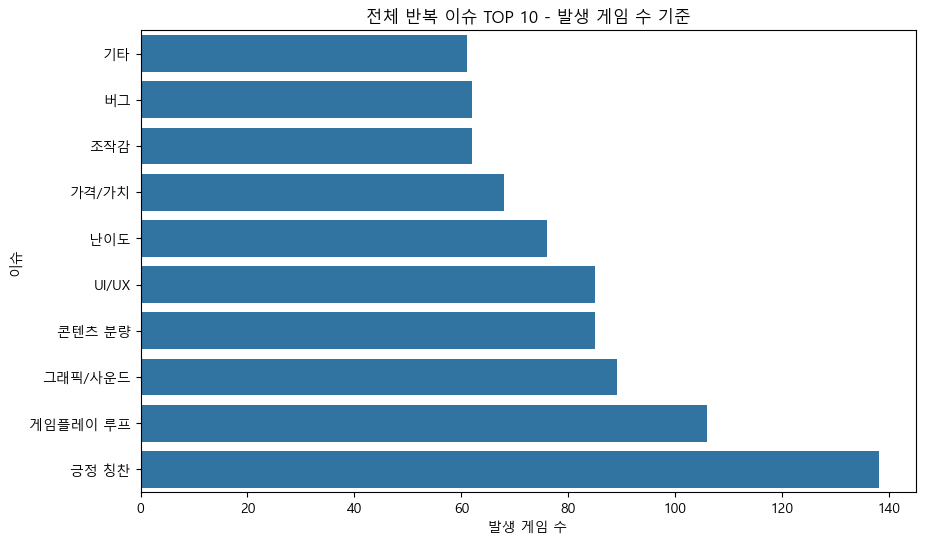

In [40]:
# ============================================================
# 전체 반복 이슈 TOP 10
# ============================================================

if len(issue_summary) == 0:
    print("표시할 이슈 데이터가 없다.")
else:
    top_issue = issue_summary.head(TOP_N).copy()

    display(top_issue[[
        ISSUE_COL,
        "issue_game_count",
        "issue_game_ratio",
        "negative_game_count",
        "high_urgency_game_count",
        "total_issue_tag_count"
    ]])

    plt.figure(figsize=(10, 6))
    sns.barplot(
        data=top_issue.sort_values("issue_game_count", ascending=True),
        x="issue_game_count",
        y=ISSUE_COL
    )
    plt.title("전체 반복 이슈 TOP 10 - 발생 게임 수 기준")
    plt.xlabel("발생 게임 수")
    plt.ylabel("이슈")
    plt.show()


# 7. 긍정 요소와 부정 리스크

같은 LLM 이슈 태그라도 긍정적으로 언급될 수도 있고, 부정적으로 언급될 수도 있다.

따라서 여기서는 다음을 나누어 확인한다.

- 긍정 맥락에서 반복된 이슈
- 부정 맥락에서 반복된 이슈
- 긍정과 부정 양쪽에서 모두 나타난 이슈


In [41]:
# ============================================================
# 긍정 요소 TOP 10
# ============================================================

if len(issue_summary) == 0:
    print("표시할 이슈 데이터가 없다.")
else:
    positive_top = issue_summary.sort_values(
        ["positive_game_count", "issue_game_count"],
        ascending=False
    ).head(TOP_N)

    display(positive_top[[
        ISSUE_COL,
        "positive_game_count",
        "issue_game_count",
        "issue_game_ratio"
    ]])


,issue_name_kor,positive_game_count,issue_game_count,issue_game_ratio
6,긍정 칭찬,138,138,91.4
3,게임플레이 루프,81,106,70.2
5,그래픽/사운드,69,89,58.9
8,난이도,45,76,50.3
1,가격/가치,45,68,45.0
15,스토리,36,48,31.8
19,콘텐츠 분량,35,85,56.3
0,UI/UX,24,85,56.3
2,개발사 소통,22,32,21.2
17,조작감,15,62,41.1


,issue_name_kor,negative_game_count,high_urgency_game_count,issue_game_count,issue_game_ratio
3,게임플레이 루프,80,56,106,70.2
0,UI/UX,77,46,85,56.3
11,버그,61,47,62,41.1
19,콘텐츠 분량,60,27,85,56.3
17,조작감,53,46,62,41.1
5,그래픽/사운드,52,41,89,58.9
8,난이도,49,33,76,50.3
7,기타,40,22,61,40.4
10,밸런스,38,28,45,29.8
1,가격/가치,33,20,68,45.0


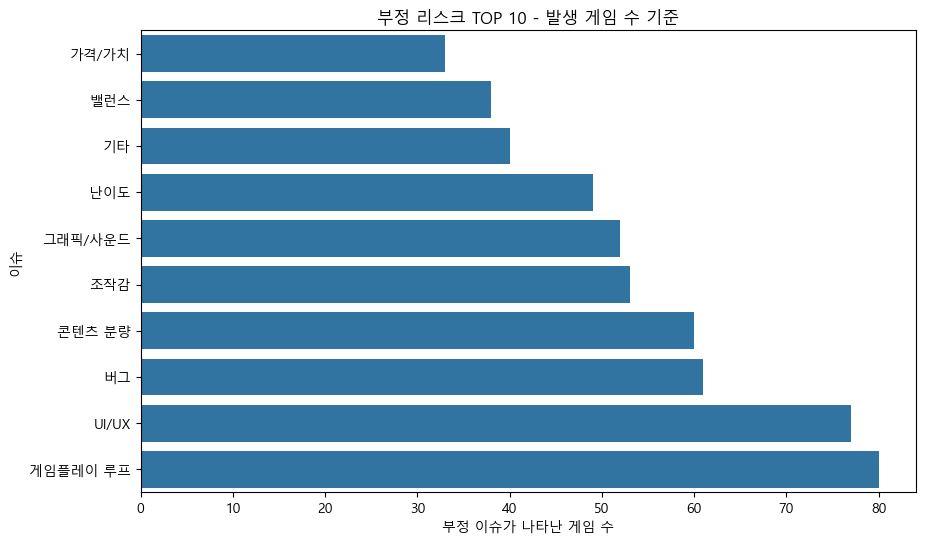

In [42]:
# ============================================================
# 부정 리스크 TOP 10
# ============================================================

if len(issue_summary) == 0:
    print("표시할 이슈 데이터가 없다.")
else:
    negative_top = issue_summary.sort_values(
        ["negative_game_count", "high_urgency_game_count", "issue_game_count"],
        ascending=False
    ).head(TOP_N)

    display(negative_top[[
        ISSUE_COL,
        "negative_game_count",
        "high_urgency_game_count",
        "issue_game_count",
        "issue_game_ratio"
    ]])

    plt.figure(figsize=(10, 6))
    sns.barplot(
        data=negative_top.sort_values("negative_game_count", ascending=True),
        x="negative_game_count",
        y=ISSUE_COL
    )
    plt.title("부정 리스크 TOP 10 - 발생 게임 수 기준")
    plt.xlabel("부정 이슈가 나타난 게임 수")
    plt.ylabel("이슈")
    plt.show()


In [43]:
# ============================================================
# 긍정과 부정이 함께 나타나는 이슈
# ============================================================
# 이런 이슈는 장점이 될 수도 있고, 단점이 될 수도 있는 평가축이다.

if len(issue_summary) == 0:
    print("표시할 이슈 데이터가 없다.")
else:
    overlap_top = issue_summary[issue_summary["both_positive_negative_game_count"] > 0].copy()
    overlap_top = overlap_top.sort_values(
        ["both_positive_negative_game_count", "issue_game_count"],
        ascending=False
    ).head(TOP_N)

    display(overlap_top[[
        ISSUE_COL,
        "both_positive_negative_game_count",
        "positive_game_count",
        "negative_game_count",
        "issue_game_count"
    ]])


,issue_name_kor,both_positive_negative_game_count,positive_game_count,negative_game_count,issue_game_count
3,게임플레이 루프,61,81,80,106
5,그래픽/사운드,35,69,52,89
8,난이도,26,45,49,76
19,콘텐츠 분량,24,35,60,85
0,UI/UX,17,24,77,85
15,스토리,17,36,28,48
1,가격/가치,12,45,33,68
17,조작감,9,15,53,62
9,멀티/네트워크,7,10,16,20
11,버그,6,7,61,62


# 8. High urgency 이슈

`urgency`는 LLM이 리뷰 내용을 보고 개선 시급도를 분류한 값이다.

여기서는 High urgency가 많이 나온 이슈를 보되,  
단순 태그 수가 아니라 **High urgency가 나타난 게임 수**를 기준으로 본다.


,issue_name_kor,high_urgency_game_count,negative_game_count,issue_game_count,issue_game_ratio
3,게임플레이 루프,56,80,106,70.2
11,버그,47,61,62,41.1
0,UI/UX,46,77,85,56.3
17,조작감,46,53,62,41.1
6,긍정 칭찬,45,0,138,91.4
5,그래픽/사운드,41,52,89,58.9
8,난이도,33,49,76,50.3
10,밸런스,28,38,45,29.8
19,콘텐츠 분량,27,60,85,56.3
7,기타,22,40,61,40.4


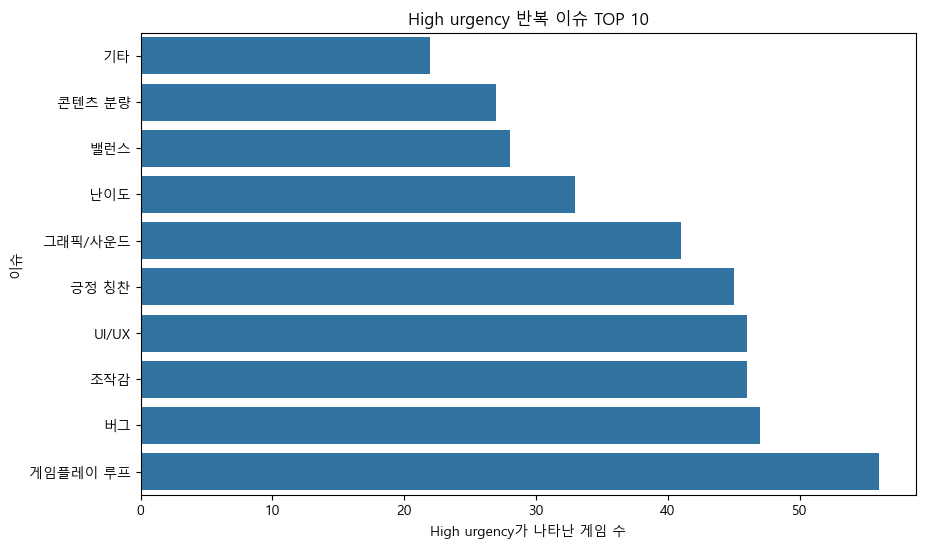

In [44]:
# ============================================================
# High urgency 반복 이슈 TOP 10
# ============================================================

if len(issue_summary) == 0:
    print("표시할 이슈 데이터가 없다.")
else:
    high_top = issue_summary.sort_values(
        ["high_urgency_game_count", "negative_game_count", "issue_game_count"],
        ascending=False
    ).head(TOP_N)

    display(high_top[[
        ISSUE_COL,
        "high_urgency_game_count",
        "negative_game_count",
        "issue_game_count",
        "issue_game_ratio"
    ]])

    plt.figure(figsize=(10, 6))
    sns.barplot(
        data=high_top.sort_values("high_urgency_game_count", ascending=True),
        x="high_urgency_game_count",
        y=ISSUE_COL
    )
    plt.title("High urgency 반복 이슈 TOP 10")
    plt.xlabel("High urgency가 나타난 게임 수")
    plt.ylabel("이슈")
    plt.show()


# 9. 가격대별 반복 이슈

가격대별로 어떤 이슈가 반복되는지 확인한다.

해석 기준은 다음과 같다.

```text
가격대 안의 전체 게임 수 중, 해당 이슈가 나타난 게임 비율
```

게임 수가 너무 적은 가격대는 강하게 해석하지 않는다.


In [45]:
# ============================================================
# 가격대별 반복 이슈
# ============================================================

if len(game_issue_df) == 0 or "price_group" not in review_df.columns:
    print("가격대별 분석을 할 수 없다.")
else:
    game_meta = review_df[[GAME_ID_COL, GAME_NAME_COL, "price_group"]].drop_duplicates()
    game_issue_price = game_issue_df.merge(
        game_meta,
        on=[GAME_ID_COL, GAME_NAME_COL],
        how="left"
    )

    price_game_count = (
        game_meta
        .dropna(subset=["price_group"])
        .groupby("price_group")[GAME_ID_COL]
        .nunique()
        .reset_index(name="group_game_count")
    )

    price_issue = (
        game_issue_price
        .dropna(subset=["price_group"])
        .groupby(["price_group", ISSUE_COL])[GAME_ID_COL]
        .nunique()
        .reset_index(name="issue_game_count")
    )

    price_issue = price_issue.merge(price_game_count, on="price_group", how="left")
    price_issue["issue_game_ratio"] = (
        price_issue["issue_game_count"] / price_issue["group_game_count"] * 100
    ).round(1)

    price_issue = price_issue[price_issue["group_game_count"] >= MIN_GAMES_PER_GROUP]
    price_issue = price_issue.sort_values(
        ["price_group", "issue_game_ratio", "issue_game_count"],
        ascending=[True, False, False]
    )

    display(price_issue.head(30))


,price_group,issue_name_kor,issue_game_count,group_game_count,issue_game_ratio
6,0-5,긍정 칭찬,53,54,98.1
3,0-5,게임플레이 루프,32,54,59.3
5,0-5,그래픽/사운드,28,54,51.9
19,0-5,콘텐츠 분량,25,54,46.3
8,0-5,난이도,24,54,44.4
0,0-5,UI/UX,22,54,40.7
1,0-5,가격/가치,21,54,38.9
11,0-5,버그,15,54,27.8
17,0-5,조작감,15,54,27.8
7,0-5,기타,14,54,25.9


# 10. 장르별 반복 이슈

하나의 게임은 여러 장르를 가질 수 있다.  
그래서 `genres_text`를 쉼표 기준으로 나누어 장르별 이슈를 확인한다.


In [46]:
# ============================================================
# 장르별 반복 이슈
# ============================================================

if len(game_issue_df) == 0 or "genres_text" not in review_df.columns:
    print("장르별 분석을 할 수 없다.")
else:
    game_genre = review_df[[GAME_ID_COL, GAME_NAME_COL, "genres_text"]].drop_duplicates()
    game_genre["genre"] = game_genre["genres_text"].fillna("").str.split(",")
    game_genre = game_genre.explode("genre")
    game_genre["genre"] = game_genre["genre"].astype(str).str.strip()
    game_genre = game_genre[game_genre["genre"] != ""]

    genre_game_count = (
        game_genre
        .groupby("genre")[GAME_ID_COL]
        .nunique()
        .reset_index(name="group_game_count")
    )

    game_issue_genre = game_issue_df.merge(
        game_genre[[GAME_ID_COL, GAME_NAME_COL, "genre"]],
        on=[GAME_ID_COL, GAME_NAME_COL],
        how="left"
    )

    genre_issue = (
        game_issue_genre
        .dropna(subset=["genre"])
        .groupby(["genre", ISSUE_COL])[GAME_ID_COL]
        .nunique()
        .reset_index(name="issue_game_count")
    )

    genre_issue = genre_issue.merge(genre_game_count, on="genre", how="left")
    genre_issue["issue_game_ratio"] = (
        genre_issue["issue_game_count"] / genre_issue["group_game_count"] * 100
    ).round(1)

    genre_issue = genre_issue[genre_issue["group_game_count"] >= MIN_GAMES_PER_GROUP]
    genre_issue = genre_issue.sort_values(
        ["genre", "issue_game_ratio", "issue_game_count"],
        ascending=[True, False, False]
    )

    display(genre_issue.head(30))


,genre,issue_name_kor,issue_game_count,group_game_count,issue_game_ratio
6,Action,긍정 칭찬,56,62,90.3
3,Action,게임플레이 루프,45,62,72.6
8,Action,난이도,38,62,61.3
5,Action,그래픽/사운드,36,62,58.1
0,Action,UI/UX,34,62,54.8
17,Action,조작감,32,62,51.6
19,Action,콘텐츠 분량,32,62,51.6
1,Action,가격/가치,28,62,45.2
7,Action,기타,26,62,41.9
11,Action,버그,26,62,41.9


# 11. Steam 태그별 반복 이슈

Steam 태그는 종류가 많아서, 너무 적은 게임에만 붙은 태그는 제외한다.

여기서는 최소 `MIN_GAMES_PER_TAG`개 이상의 게임에 나타난 태그만 확인한다.


In [47]:
# ============================================================
# Steam 태그별 반복 이슈
# ============================================================

if len(game_issue_df) == 0 or "top_steam_tags_text" not in review_df.columns:
    print("Steam 태그별 분석을 할 수 없다.")
else:
    game_tag = review_df[[GAME_ID_COL, GAME_NAME_COL, "top_steam_tags_text"]].drop_duplicates()
    game_tag["steam_tag"] = game_tag["top_steam_tags_text"].fillna("").str.split(",")
    game_tag = game_tag.explode("steam_tag")
    game_tag["steam_tag"] = game_tag["steam_tag"].astype(str).str.strip()
    game_tag = game_tag[game_tag["steam_tag"] != ""]

    tag_game_count = (
        game_tag
        .groupby("steam_tag")[GAME_ID_COL]
        .nunique()
        .reset_index(name="group_game_count")
    )

    game_issue_tag = game_issue_df.merge(
        game_tag[[GAME_ID_COL, GAME_NAME_COL, "steam_tag"]],
        on=[GAME_ID_COL, GAME_NAME_COL],
        how="left"
    )

    tag_issue = (
        game_issue_tag
        .dropna(subset=["steam_tag"])
        .groupby(["steam_tag", ISSUE_COL])[GAME_ID_COL]
        .nunique()
        .reset_index(name="issue_game_count")
    )

    tag_issue = tag_issue.merge(tag_game_count, on="steam_tag", how="left")
    tag_issue["issue_game_ratio"] = (
        tag_issue["issue_game_count"] / tag_issue["group_game_count"] * 100
    ).round(1)

    tag_issue = tag_issue[tag_issue["group_game_count"] >= MIN_GAMES_PER_TAG]
    tag_issue = tag_issue.sort_values(
        ["steam_tag", "issue_game_ratio", "issue_game_count"],
        ascending=[True, False, False]
    )

    display(tag_issue.head(30))


,steam_tag,issue_name_kor,issue_game_count,group_game_count,issue_game_ratio
59,2D,긍정 칭찬,31,34,91.2
56,2D,게임플레이 루프,24,34,70.6
61,2D,난이도,22,34,64.7
53,2D,UI/UX,20,34,58.8
58,2D,그래픽/사운드,19,34,55.9
72,2D,콘텐츠 분량,16,34,47.1
54,2D,가격/가치,14,34,41.2
60,2D,기타,11,34,32.4
64,2D,버그,11,34,32.4
63,2D,밸런스,9,34,26.5


# 12. 플레이 방식별 반복 이슈

`categories_text`에는 Steam 기능도 섞여 있다.  
그래서 여기서는 아주 단순하게 플레이 방식을 다시 묶는다.

- Co-op 포함
- Multi-player 포함
- Single-player 중심
- 기타


In [48]:
# ============================================================
# 플레이 방식 간단 분류
# ============================================================
# categories_text에 Co-op, Multi-player, Online이 들어가면
# 멀티/협동 요소가 있는 게임으로 분류한다.
# 그 외는 Single-player 중심으로 분류한다.

review_df["categories_text"] = review_df["categories_text"].fillna("").astype(str)

review_df["play_style_group"] = "Single-player 중심"

review_df.loc[
    review_df["categories_text"].str.contains("Co-op|Multi-player|Online", case=False, regex=True),
    "play_style_group"
] = "멀티/협동 요소 포함"

# tag_df에도 play_style_group 붙인다.
tag_df = tag_df.merge(
    review_df[["recommendationid", "play_style_group"]].drop_duplicates("recommendationid"),
    on="recommendationid",
    how="left"
)

# 플레이 방식별 리뷰 수 확인
play_sample = (
    review_df
    .groupby("play_style_group")["recommendationid"]
    .nunique()
    .reset_index()
)

play_sample.columns = ["플레이 방식", "리뷰 수"]

display(play_sample)


,플레이 방식,리뷰 수
0,Single-player 중심,3159
1,멀티/협동 요소 포함,611


In [49]:
# ============================================================
# 플레이 방식별 반복 이슈
# ============================================================

if len(game_issue_df) == 0:
    print("플레이 방식별 분석을 할 수 없다.")
else:
    game_play = review_df[[GAME_ID_COL, GAME_NAME_COL, "play_style_group"]].drop_duplicates()

    play_game_count = (
        game_play
        .groupby("play_style_group")[GAME_ID_COL]
        .nunique()
        .reset_index(name="group_game_count")
    )

    game_issue_play = game_issue_df.merge(
        game_play,
        on=[GAME_ID_COL, GAME_NAME_COL],
        how="left"
    )

    play_issue = (
        game_issue_play
        .groupby(["play_style_group", ISSUE_COL])[GAME_ID_COL]
        .nunique()
        .reset_index(name="issue_game_count")
    )

    play_issue = play_issue.merge(play_game_count, on="play_style_group", how="left")
    play_issue["issue_game_ratio"] = (
        play_issue["issue_game_count"] / play_issue["group_game_count"] * 100
    ).round(1)

    play_issue = play_issue[play_issue["group_game_count"] >= MIN_GAMES_PER_GROUP]
    play_issue = play_issue.sort_values(
        ["play_style_group", "issue_game_ratio", "issue_game_count"],
        ascending=[True, False, False]
    )

    display(play_issue.head(30))


,play_style_group,issue_name_kor,issue_game_count,group_game_count,issue_game_ratio
6,Single-player 중심,긍정 칭찬,113,124,91.1
3,Single-player 중심,게임플레이 루프,87,124,70.2
5,Single-player 중심,그래픽/사운드,75,124,60.5
0,Single-player 중심,UI/UX,69,124,55.6
19,Single-player 중심,콘텐츠 분량,69,124,55.6
8,Single-player 중심,난이도,59,124,47.6
1,Single-player 중심,가격/가치,55,124,44.4
11,Single-player 중심,버그,50,124,40.3
17,Single-player 중심,조작감,49,124,39.5
7,Single-player 중심,기타,48,124,38.7


# 13. 출시 전 체크리스트 생성 준비

여기서는 앞에서 만든 반복 이슈 분석 결과를 사용해 **개발자 조건에 맞는 출시 전 체크리스트**를 만든다.

체크리스트는 바로 LLM에게 리뷰 원문을 보내서 만들지 않는다.  
먼저 조건에 맞는 게임을 찾고, 그 게임들에서 반복된 이슈를 정리한 뒤, 그 요약표를 LLM에게 전달한다.

체크리스트 우선순위는 다음처럼 나눈다.

| 우선순위 | 의미 |
|---|---|
| 상 | 출시 전 반드시 점검해야 할 가능성이 높은 항목 |
| 중 | 가능하면 점검하면 좋은 항목 |
| 하 | 참고용으로 확인할 항목 |


In [50]:
# ============================================================
# 13-1. 체크리스트 생성 조건 설정
# ============================================================
# 개발자가 만들려는 게임 조건을 여기에 입력한다.
# None 또는 빈 리스트([])로 두면 해당 조건은 사용하지 않는다.

USER_CONDITION = {
    "genres": ["Action"],                 # 예: ["Action"], ["RPG", "Adventure"]
    "price_group": None,                 # 예: "0-5", "5-10", "10-20", "20-40", "40+", "free"
    "steam_tags": [],                    # 예: ["Roguelike", "Pixel Graphics"]
    "steam_tag_match": "any",           # "any": 하나라도 포함, "all": 전부 포함
    "play_style_group": None             # 예: "Single-player 중심", "멀티/협동 요소 포함"
}

# 체크리스트에 사용할 이슈 개수
CHECKLIST_TOP_N = 15

# 조건에 맞는 게임 수가 너무 적을 때 경고하기 위한 기준
MIN_CONDITION_GAMES = 5

print("개발자 입력 조건")
for key, value in USER_CONDITION.items():
    print(f"- {key}: {value}")


개발자 입력 조건
- genres: ['Action']
- price_group: None
- steam_tags: []
- steam_tag_match: any
- play_style_group: None


In [51]:
# ============================================================
# 13-2. 조건 매칭용 게임 정보 만들기
# ============================================================
# review_df는 리뷰 단위 데이터라서 같은 게임이 여러 번 나온다.
# 여기서는 게임 1개당 1행만 남겨서 조건 매칭에 사용한다.

condition_cols = [
    GAME_ID_COL,
    GAME_NAME_COL,
    "price_group",
    "genres_text",
    "top_steam_tags_text",
    "play_style_group"
]

# 실제 존재하는 컬럼만 사용한다.
condition_cols = [col for col in condition_cols if col in review_df.columns]

game_condition_df = (
    review_df[condition_cols]
    .drop_duplicates(subset=[GAME_ID_COL])
    .copy()
)

# 문자열 결측치는 빈 문자열로 처리한다.
for col in ["genres_text", "top_steam_tags_text", "play_style_group", "price_group"]:
    if col in game_condition_df.columns:
        game_condition_df[col] = game_condition_df[col].fillna("").astype(str)

print("조건 매칭용 게임 수:", len(game_condition_df))
display(game_condition_df.head())


조건 매칭용 게임 수: 151


,appid,game_name,price_group,genres_text,top_steam_tags_text,play_style_group
0,571740,Golf It!,0-5,"Casual, Indie, Simulation, Sports","Multiplayer, Mini Golf, Golf, Casual, Sports, Funny, Online Co-Op, Singleplayer, Simulation, Level Editor",멀티/협동 요소 포함
48,603390,Stone Story RPG,20-40,"Adventure, Casual, Indie, RPG","RPG, Adventure, Casual, Indie, Programming, Retro, Idler, Logic, Text-Based, Great Soundtrack",Single-player 중심
55,638990,"UNDYING - ""KINGDOM""",10-20,"Adventure, Indie","Story Rich, Multiple Endings, Action RPG, Survival, Adventure, Zombies, Female Protagonist, Post-apocalyptic, Crafti...",Single-player 중심
85,695330,SEASON: A letter to the future,10-20,"Adventure, Casual, Indie","Open World, Mystery, Visual Novel, Narrative, Female Protagonist, Emotional, Interactive Fiction, Exploration, Atmos...",Single-player 중심
184,824600,HROT,10-20,"Action, Indie","Retro, FPS, Shooter, Boomer Shooter, Indie, First-Person, Action, Singleplayer, Old School, Gore",Single-player 중심


In [52]:
# ============================================================
# 13-3. 개발자 조건에 맞는 게임 찾기
# ============================================================
# 어렵게 만들지 않고, 조건을 하나씩 적용한다.

condition_game_df = game_condition_df.copy()

# 1) 장르 조건
if USER_CONDITION["genres"]:
    genre_pattern = "|".join(USER_CONDITION["genres"])
    condition_game_df = condition_game_df[
        condition_game_df["genres_text"].str.contains(genre_pattern, case=False, regex=True)
    ]

# 2) 가격대 조건
if USER_CONDITION["price_group"]:
    condition_game_df = condition_game_df[
        condition_game_df["price_group"] == USER_CONDITION["price_group"]
    ]

# 3) Steam 태그 조건
if USER_CONDITION["steam_tags"]:
    tag_list = USER_CONDITION["steam_tags"]

    if USER_CONDITION.get("steam_tag_match") == "all":
        for tag in tag_list:
            condition_game_df = condition_game_df[
                condition_game_df["top_steam_tags_text"].str.contains(tag, case=False, regex=False)
            ]
    else:
        tag_pattern = "|".join(tag_list)
        condition_game_df = condition_game_df[
            condition_game_df["top_steam_tags_text"].str.contains(tag_pattern, case=False, regex=True)
        ]

# 4) 플레이 방식 조건
if USER_CONDITION["play_style_group"]:
    condition_game_df = condition_game_df[
        condition_game_df["play_style_group"] == USER_CONDITION["play_style_group"]
    ]

condition_game_count = condition_game_df[GAME_ID_COL].nunique()

print("조건에 맞는 게임 수:", condition_game_count)

if condition_game_count < MIN_CONDITION_GAMES:
    print("주의: 조건에 맞는 게임 수가 적다. 결과는 참고용으로 해석하는 것이 좋다.")

display(condition_game_df.head(20))


조건에 맞는 게임 수: 62


,appid,game_name,price_group,genres_text,top_steam_tags_text,play_style_group
184,824600,HROT,10-20,"Action, Indie","Retro, FPS, Shooter, Boomer Shooter, Indie, First-Person, Action, Singleplayer, Old School, Gore",Single-player 중심
284,1054510,Survivalist: Invisible Strain,10-20,"Action, Adventure, Indie, RPG, Simulation, Strategy","Open World Survival Craft, Colony Sim, RPG, RTS, Action, Third Person, Base-Building, Post-apocalyptic, Character Cu...",멀티/협동 요소 포함
331,1133060,Anarchy: Wolf's law,0-5,"Action, Adventure, Indie, Simulation, Strategy","Survival, Realistic, Multiplayer, Zombies, Crafting, Open World Survival Craft, Action, Open World, Shooter, Heist",멀티/협동 요소 포함
548,1216350,Time Hacker,10-20,"Action, Adventure, Casual, Indie, Simulation","VR, Bullet Time, First-Person, Time Manipulation, Indie, Action, Shooter, Adventure, Simulation, Casual",Single-player 중심
549,1303010,Vincemus - Air Combat,10-20,"Action, Indie, Simulation","Action, Simulation, Flight, Military, Indie, War, World War II, Arcade, Shooter, Wargame",Single-player 중심
556,1366560,MiLE HiGH TAXi,10-20,"Action, Indie, Racing, Simulation","Flight, Racing, Driving, Arcade, Action-Adventure, Female Protagonist, 3D, Third Person, Controller, Open World",Single-player 중심
695,1409200,HYPERVIOLENT,10-20,"Action, Indie","Early Access, Lovecraftian, FPS, Boomer Shooter, Shooter, Immersive Sim, First-Person, RPG, Horror, 3D",Single-player 중심
836,1445790,Make Way,10-20,"Action, Casual, Indie, Racing","Local Multiplayer, Multiplayer, Party, Racing, PvP, Building, Funny, Family Friendly, Arcade, Action",멀티/협동 요소 포함
870,1466060,Tainted Grail: The Fall of Avalon,40+,"Action, Adventure, Indie, RPG","Adventure, Open World, Dark Fantasy, RPG, First-Person, Third Person, Exploration, Character Customization, Singlepl...",Single-player 중심
971,1511880,Slime Heroes,20-40,"Action, Adventure, Indie, RPG","Colorful, Local Co-Op, Fantasy, Indie, Character Customization, Exploration, Puzzle, Souls-like, Action-Adventure, 3D",멀티/협동 요소 포함


In [53]:
# ============================================================
# 13-4. 조건에 맞는 게임의 반복 이슈 정리
# ============================================================
# 조건에 맞는 게임들 안에서 어떤 이슈가 여러 게임에 반복됐는지 계산한다.

if len(game_issue_df) == 0:
    print("game_issue_df가 비어 있어서 체크리스트 근거를 만들 수 없다.")
    condition_issue_summary = pd.DataFrame()
else:
    condition_game_ids = condition_game_df[GAME_ID_COL].unique()

    condition_game_issue_df = game_issue_df[
        game_issue_df[GAME_ID_COL].isin(condition_game_ids)
    ].copy()

    if len(condition_game_issue_df) == 0:
        print("조건에 맞는 이슈 데이터가 없다.")
        condition_issue_summary = pd.DataFrame()
    else:
        condition_issue_summary = (
            condition_game_issue_df
            .groupby(ISSUE_COL)
            .agg(
                issue_game_count=(GAME_ID_COL, "nunique"),
                positive_game_count=("positive_present", "sum"),
                negative_game_count=("negative_present", "sum"),
                high_urgency_game_count=("high_urgency_present", "sum"),
                both_positive_negative_game_count=("both_positive_negative_present", "sum"),
                total_issue_review_count=("issue_review_count", "sum"),
                total_issue_tag_count=("issue_tag_count", "sum")
            )
            .reset_index()
        )

        condition_issue_summary["condition_game_count"] = condition_game_count
        condition_issue_summary["issue_game_ratio"] = (
            condition_issue_summary["issue_game_count"] / condition_game_count * 100
        ).round(1)

        condition_issue_summary = condition_issue_summary.sort_values(
            ["high_urgency_game_count", "negative_game_count", "issue_game_count"],
            ascending=False
        )

print("조건 내 반복 이슈 수:", len(condition_issue_summary))
display(condition_issue_summary.head(CHECKLIST_TOP_N))


조건 내 반복 이슈 수: 21


,issue_name_kor,issue_game_count,positive_game_count,negative_game_count,high_urgency_game_count,both_positive_negative_game_count,total_issue_review_count,total_issue_tag_count,condition_game_count,issue_game_ratio
3,게임플레이 루프,45,34,35,28,27,440,441,62,72.6
17,조작감,32,7,29,27,4,117,117,62,51.6
0,UI/UX,34,10,32,20,8,127,128,62,54.8
11,버그,26,2,26,20,2,124,124,62,41.9
6,긍정 칭찬,56,56,0,19,0,900,900,62,90.3
8,난이도,38,22,21,17,11,157,157,62,61.3
5,그래픽/사운드,36,26,22,16,14,180,184,62,58.1
10,밸런스,19,3,16,14,0,81,82,62,30.6
13,성능,19,6,13,12,0,43,43,62,30.6
7,기타,26,5,18,11,1,92,93,62,41.9


In [54]:
# ============================================================
# 13-5. 상/중/하 우선순위 후보 만들기
# ============================================================
# LLM에게 보내기 전에, 반복 이슈에 간단한 우선순위를 먼저 붙인다.
# 기준은 단순하게 잡는다.
# - High urgency가 여러 게임에서 반복되거나, 부정 이슈가 여러 게임에서 반복되면 '상'
# - 일부 게임에서 반복되면 '중'
# - 그 외는 '하'

def get_priority(row):
    issue_ratio = row["issue_game_ratio"]
    negative_games = row["negative_game_count"]
    high_games = row["high_urgency_game_count"]
    issue_games = row["issue_game_count"]

    # 표본 게임 수가 10개 이상일 때 기준
    if row["condition_game_count"] >= 10:
        if high_games >= 3 or negative_games >= 5 or issue_ratio >= 30:
            return "상"
        elif high_games >= 1 or negative_games >= 3 or issue_ratio >= 15:
            return "중"
        else:
            return "하"

    # 표본 게임 수가 적을 때는 비율이 쉽게 커질 수 있으므로 조금 조심해서 본다.
    else:
        if high_games >= 2 or negative_games >= 3 or issue_ratio >= 40:
            return "상"
        elif high_games >= 1 or negative_games >= 2 or issue_ratio >= 20:
            return "중"
        else:
            return "하"

if len(condition_issue_summary) > 0:
    condition_issue_summary["priority_level"] = condition_issue_summary.apply(get_priority, axis=1)

    checklist_evidence_df = condition_issue_summary.head(CHECKLIST_TOP_N).copy()

    display(checklist_evidence_df[[
        ISSUE_COL,
        "priority_level",
        "issue_game_count",
        "issue_game_ratio",
        "negative_game_count",
        "high_urgency_game_count",
        "both_positive_negative_game_count"
    ]])
else:
    checklist_evidence_df = pd.DataFrame()
    print("체크리스트 근거 데이터가 없다.")


,issue_name_kor,priority_level,issue_game_count,issue_game_ratio,negative_game_count,high_urgency_game_count,both_positive_negative_game_count
3,게임플레이 루프,상,45,72.6,35,28,27
17,조작감,상,32,51.6,29,27,4
0,UI/UX,상,34,54.8,32,20,8
11,버그,상,26,41.9,26,20,2
6,긍정 칭찬,상,56,90.3,0,19,0
8,난이도,상,38,61.3,21,17,11
5,그래픽/사운드,상,36,58.1,22,16,14
10,밸런스,상,19,30.6,16,14,0
13,성능,상,19,30.6,13,12,0
7,기타,상,26,41.9,18,11,1


# 14. LLM으로 출시 전 체크리스트 생성

이 단계에서는 위에서 만든 `checklist_evidence_df`를 LLM에게 전달해서, 개발자가 보기 쉬운 체크리스트로 정리한다.

중요한 점은 다음과 같다.

1. 리뷰 원문 전체를 다시 보내지 않는다.
2. 조건에 맞는 게임들의 반복 이슈 요약표만 보낸다.
3. 체크리스트는 `상`, `중`, `하` 우선순위로 나눈다.
4. 근거가 약하면 단정하지 않고 참고용이라고 표현한다.


In [55]:
# ============================================================
# 14-1. 체크리스트 LLM 실행 설정
# ============================================================
# RUN_CHECKLIST_LLM = False이면 LLM을 호출하지 않고 프롬프트만 확인한다.
# 프롬프트와 근거표를 확인한 뒤 True로 바꾸면 된다.

RUN_CHECKLIST_LLM = False
SAVE_CHECKLIST_RESULT = True

# LLM 호출 설정
CHECKLIST_MAX_RETRIES = 3
CHECKLIST_REQUEST_SLEEP_SEC = 1

# 결과 저장 폴더
CHECKLIST_OUTPUT_DIR = OUTPUT_DIR / "prelaunch_checklist"
CHECKLIST_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

CHECKLIST_PROMPT_PATH = CHECKLIST_OUTPUT_DIR / "prelaunch_checklist_prompt.txt"
CHECKLIST_JSON_PATH = CHECKLIST_OUTPUT_DIR / "prelaunch_checklist_result.json"
CHECKLIST_MD_PATH = CHECKLIST_OUTPUT_DIR / "prelaunch_checklist_result.md"
CHECKLIST_EVIDENCE_PATH = CHECKLIST_OUTPUT_DIR / "prelaunch_checklist_evidence.csv"

print("RUN_CHECKLIST_LLM:", RUN_CHECKLIST_LLM)
print("체크리스트 결과 저장 폴더:", CHECKLIST_OUTPUT_DIR)


RUN_CHECKLIST_LLM: False
체크리스트 결과 저장 폴더: c:\Users\joon5\Documents\github\steam-indie-game-analysis\data\outputs\main_allgames_d0-d30\prelaunch_checklist


In [56]:
# ============================================================
# 14-2. Vertex AI / PydanticAI 설정
# ============================================================
# 03_run_llm_allgames_analysi.ipynb와 비슷한 방식으로 설정한다.
# 실제 LLM 호출을 하지 않을 때는 프로젝트 ID가 없어도 된다.

import os
import json
import time
from typing import List, Optional
from pydantic import BaseModel, Field

try:
    from dotenv import load_dotenv
    from pydantic_ai import Agent
    from pydantic_ai.models.google import GoogleModel, GoogleModelSettings
    from pydantic_ai.providers.google import GoogleProvider
except Exception as e:
    Agent = None
    GoogleModel = None
    GoogleModelSettings = None
    GoogleProvider = None
    print("PydanticAI 관련 라이브러리를 불러오지 못했다.")
    print("RUN_CHECKLIST_LLM=False이면 프롬프트 확인은 가능하다.")
    print("오류:", e)

# .env 파일이 있으면 불러온다.
try:
    load_dotenv()
    load_dotenv(ROOT / ".env")
except Exception:
    pass

GOOGLE_CLOUD_PROJECT = (
    os.getenv("GOOGLE_CLOUD_PROJECT")
    or os.getenv("VERTEX_PROJECT_ID")
    or os.getenv("GCP_PROJECT_ID")
)

GOOGLE_CLOUD_LOCATION = (
    os.getenv("GOOGLE_CLOUD_LOCATION")
    or os.getenv("VERTEX_LOCATION")
    or "global"
)

GEMINI_MODEL = os.getenv("GEMINI_MODEL", "gemini-3.1-flash-lite-preview")

if GOOGLE_CLOUD_PROJECT and GoogleProvider is not None:
    vertex_provider = GoogleProvider(
        vertexai=True,
        project=GOOGLE_CLOUD_PROJECT,
        location=GOOGLE_CLOUD_LOCATION,
    )

    vertex_model = GoogleModel(
        GEMINI_MODEL,
        provider=vertex_provider,
    )

    print("Vertex AI project:", GOOGLE_CLOUD_PROJECT)
    print("Vertex AI location:", GOOGLE_CLOUD_LOCATION)
    print("Gemini model:", GEMINI_MODEL)
    print("Vertex 모델 생성: O")
else:
    vertex_provider = None
    vertex_model = None

    print("Vertex AI project: 미설정 또는 라이브러리 없음")
    print("Vertex 모델 생성: X")
    print("실제 LLM 실행 전 .env 또는 환경변수 설정을 확인한다.")


Vertex AI project: gen-lang-client-0587784564
Vertex AI location: global
Gemini model: gemini-3.1-flash-lite-preview
Vertex 모델 생성: O


In [57]:
# ============================================================
# 14-3. 체크리스트 출력 스키마 정의
# ============================================================
# LLM이 일정한 형식으로 결과를 반환하도록 Pydantic 모델을 만든다.

class PreLaunchChecklistItem(BaseModel):
    priority: str = Field(description="점검 우선순위. 상, 중, 하 중 하나")
    check_item: str = Field(description="출시 전 확인해야 할 점검 항목")
    reason: str = Field(description="왜 이 항목을 점검해야 하는지")
    evidence_issue: str = Field(description="근거가 된 반복 이슈명")
    suggested_action: str = Field(description="개발자가 할 수 있는 구체적인 점검 또는 개선 행동")


class PreLaunchChecklistResult(BaseModel):
    title: str = Field(description="체크리스트 제목")
    condition_summary: str = Field(description="입력 조건 요약")
    data_summary: str = Field(description="근거 데이터 요약. 조건에 맞는 게임 수와 해석 주의점 포함")
    high_priority: List[PreLaunchChecklistItem] = Field(description="상 우선순위 체크리스트")
    mid_priority: List[PreLaunchChecklistItem] = Field(description="중 우선순위 체크리스트")
    low_priority: List[PreLaunchChecklistItem] = Field(description="하 우선순위 체크리스트")
    caution: str = Field(description="해석 시 주의점")

print("체크리스트 출력 스키마 준비 완료")


체크리스트 출력 스키마 준비 완료


In [58]:
# ============================================================
# 14-4. LLM에 전달할 프롬프트 만들기
# ============================================================
# 근거표를 너무 길게 보내지 않도록 필요한 컬럼만 사용한다.

def make_condition_text(condition):
    lines = []
    lines.append(f"장르: {condition.get('genres') or '제한 없음'}")
    lines.append(f"가격대: {condition.get('price_group') or '제한 없음'}")
    lines.append(f"Steam 태그: {condition.get('steam_tags') or '제한 없음'}")
    lines.append(f"Steam 태그 매칭 방식: {condition.get('steam_tag_match')}")
    lines.append(f"플레이 방식: {condition.get('play_style_group') or '제한 없음'}")
    return "\n".join(lines)

if len(checklist_evidence_df) > 0:
    evidence_cols = [
        ISSUE_COL,
        "priority_level",
        "issue_game_count",
        "issue_game_ratio",
        "negative_game_count",
        "high_urgency_game_count",
        "both_positive_negative_game_count",
        "total_issue_review_count"
    ]

    evidence_cols = [col for col in evidence_cols if col in checklist_evidence_df.columns]
    evidence_text = checklist_evidence_df[evidence_cols].to_markdown(index=False)
else:
    evidence_text = "근거 이슈 데이터가 없습니다."

condition_text = make_condition_text(USER_CONDITION)

checklist_prompt = f"""
너는 인디게임 출시 전 점검 항목을 정리하는 데이터 분석가다.

아래 입력 조건과 반복 이슈 근거표를 바탕으로,
개발자가 출시 전에 확인해야 할 체크리스트를 작성해라.

중요한 규칙:
1. 반드시 제공된 근거표를 바탕으로 작성한다.
2. 근거표에 없는 내용을 과하게 상상하지 않는다.
3. 체크리스트는 우선순위 '상', '중', '하'로 나눈다.
4. '상'은 출시 전 반드시 확인해야 할 항목이다.
5. '중'은 가능하면 확인하면 좋은 항목이다.
6. '하'는 참고용으로 확인할 항목이다.
7. 조건에 맞는 게임 수가 적으면 단정하지 말고 '참고용'이라고 표현한다.
8. 문장은 발표 보고서에 넣기 좋게 간단하고 명확하게 작성한다.

[개발자 입력 조건]
{condition_text}

[조건에 맞는 게임 수]
{condition_game_count}개

[반복 이슈 근거표]
{evidence_text}

[작성 형식]
- 제목
- 조건 요약
- 데이터 요약
- 상 우선순위 체크리스트
- 중 우선순위 체크리스트
- 하 우선순위 체크리스트
- 해석 시 주의점
""".strip()

print(checklist_prompt[:2000])

# 프롬프트 저장
CHECKLIST_PROMPT_PATH.write_text(checklist_prompt, encoding="utf-8")
print("프롬프트 저장 완료:", CHECKLIST_PROMPT_PATH)


ImportError: `Import tabulate` failed.  Use pip or conda to install the tabulate package.

In [ ]:
# ============================================================
# 14-5. PydanticAI Agent 설정
# ============================================================
# LLM 호출을 실제로 할 때만 Agent를 만든다.

if vertex_model is not None and Agent is not None:
    checklist_agent = Agent(
        vertex_model,
        output_type=PreLaunchChecklistResult,
        model_settings=GoogleModelSettings(
            temperature=0.2,
        ),
        system_prompt=(
            "너는 Steam 인디게임 리뷰 분석 결과를 바탕으로 "
            "출시 전 체크리스트를 작성하는 데이터 분석가다. "
            "제공된 근거표를 벗어나지 말고, 우선순위 상/중/하로 명확하게 정리한다."
        ),
    )
    print("체크리스트 Agent 생성 완료")
else:
    checklist_agent = None
    print("Agent를 생성하지 않았다. RUN_CHECKLIST_LLM=False이면 문제 없다.")


In [ ]:
# ============================================================
# 14-6. LLM 체크리스트 생성 실행
# ============================================================
# RUN_CHECKLIST_LLM=True일 때만 실제 LLM을 호출한다.

checklist_result = None

if not RUN_CHECKLIST_LLM:
    print("RUN_CHECKLIST_LLM=False")
    print("LLM 호출은 하지 않고, 프롬프트와 근거표만 확인한다.")

elif checklist_agent is None:
    print("Agent가 준비되지 않아 LLM을 호출할 수 없다.")
    print("Vertex AI 설정과 PydanticAI 설치 상태를 확인해야 한다.")

elif len(checklist_evidence_df) == 0:
    print("체크리스트 근거 데이터가 없어 LLM을 호출하지 않는다.")

else:
    last_error = None

    for attempt in range(1, CHECKLIST_MAX_RETRIES + 1):
        try:
            print(f"LLM 체크리스트 생성 시도: {attempt}/{CHECKLIST_MAX_RETRIES}")
            result = checklist_agent.run_sync(checklist_prompt)
            checklist_result = result.output
            print("LLM 체크리스트 생성 완료")
            break

        except Exception as e:
            last_error = e
            print("LLM 호출 실패:", e)
            time.sleep(CHECKLIST_REQUEST_SLEEP_SEC)

    if checklist_result is None:
        print("최종 실패:", last_error)

if checklist_result is not None:
    display(checklist_result.model_dump())


In [ ]:
# ============================================================
# 14-7. LLM 호출 전 확인용 간단 체크리스트 초안
# ============================================================
# LLM을 호출하지 않아도, 근거표 기준으로 간단한 초안을 확인할 수 있다.

if len(checklist_evidence_df) == 0:
    simple_checklist_df = pd.DataFrame()
    print("간단 체크리스트 초안을 만들 수 없다.")
else:
    simple_checklist_df = checklist_evidence_df[[
        ISSUE_COL,
        "priority_level",
        "issue_game_count",
        "issue_game_ratio",
        "negative_game_count",
        "high_urgency_game_count"
    ]].copy()

    simple_checklist_df = simple_checklist_df.rename(columns={
        ISSUE_COL: "점검 이슈",
        "priority_level": "우선순위",
        "issue_game_count": "발생 게임 수",
        "issue_game_ratio": "발생 게임 비율(%)",
        "negative_game_count": "부정 발생 게임 수",
        "high_urgency_game_count": "High urgency 발생 게임 수"
    })

    simple_checklist_df["체크 문장 초안"] = simple_checklist_df.apply(
        lambda row: f"[{row['우선순위']}] {row['점검 이슈']} 관련 요소를 출시 전에 점검한다.",
        axis=1
    )

    display(simple_checklist_df)


In [ ]:
# ============================================================
# 14-8. 체크리스트 결과 Markdown 변환
# ============================================================
# LLM 결과가 있으면 보고서에 붙이기 쉬운 Markdown 형태로 바꾼다.

def checklist_to_markdown(result):
    lines = []
    lines.append(f"# {result.title}")
    lines.append("")
    lines.append("## 조건 요약")
    lines.append(result.condition_summary)
    lines.append("")
    lines.append("## 데이터 요약")
    lines.append(result.data_summary)
    lines.append("")

    priority_groups = [
        ("상", result.high_priority),
        ("중", result.mid_priority),
        ("하", result.low_priority),
    ]

    for priority_name, items in priority_groups:
        lines.append(f"## {priority_name} 우선순위")
        if not items:
            lines.append("- 해당 항목 없음")
        else:
            for item in items:
                lines.append(f"- **{item.check_item}**")
                lines.append(f"  - 근거 이슈: {item.evidence_issue}")
                lines.append(f"  - 이유: {item.reason}")
                lines.append(f"  - 제안 행동: {item.suggested_action}")
        lines.append("")

    lines.append("## 해석 시 주의점")
    lines.append(result.caution)

    return "\n".join(lines)

if checklist_result is not None:
    checklist_markdown = checklist_to_markdown(checklist_result)
    print(checklist_markdown)
else:
    checklist_markdown = ""
    print("아직 LLM 체크리스트 결과가 없다.")


In [ ]:
# ============================================================
# 14-9. 체크리스트 결과 저장
# ============================================================
# LLM 결과가 없어도 근거표와 프롬프트는 저장한다.

if SAVE_CHECKLIST_RESULT:
    # 근거표 저장
    if len(checklist_evidence_df) > 0:
        checklist_evidence_df.to_csv(CHECKLIST_EVIDENCE_PATH, index=False, encoding="utf-8-sig")
        print("근거표 저장:", CHECKLIST_EVIDENCE_PATH)

    # LLM 결과 저장
    if checklist_result is not None:
        CHECKLIST_JSON_PATH.write_text(
            checklist_result.model_dump_json(indent=2),
            encoding="utf-8"
        )
        CHECKLIST_MD_PATH.write_text(checklist_markdown, encoding="utf-8")

        print("JSON 저장:", CHECKLIST_JSON_PATH)
        print("Markdown 저장:", CHECKLIST_MD_PATH)
    else:
        print("LLM 결과는 아직 없어서 JSON/Markdown은 저장하지 않았다.")


# 15. 분석 결과 저장

보고서나 Tableau에서 다시 쓰기 쉽도록 핵심 요약 테이블을 CSV로 저장한다.

체크리스트 관련 파일은 `prelaunch_checklist` 폴더에 따로 저장한다.


In [ ]:
# # ============================================================
# # 분석 결과 저장
# # ============================================================

# REPORT_OUTPUT_DIR = OUTPUT_DIR / "prelaunch_report_simple"
# REPORT_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# issue_summary.to_csv(REPORT_OUTPUT_DIR / "issue_repeat_summary.csv", index=False, encoding="utf-8-sig")
# game_issue_df.to_csv(REPORT_OUTPUT_DIR / "game_issue_summary.csv", index=False, encoding="utf-8-sig")

# # 조건별 분석 결과가 만들어진 경우에만 저장한다.
# if "price_issue" in globals():
#     price_issue.to_csv(REPORT_OUTPUT_DIR / "price_issue_summary.csv", index=False, encoding="utf-8-sig")

# if "genre_issue" in globals():
#     genre_issue.to_csv(REPORT_OUTPUT_DIR / "genre_issue_summary.csv", index=False, encoding="utf-8-sig")

# if "tag_issue" in globals():
#     tag_issue.to_csv(REPORT_OUTPUT_DIR / "steam_tag_issue_summary.csv", index=False, encoding="utf-8-sig")

# if "play_issue" in globals():
#     play_issue.to_csv(REPORT_OUTPUT_DIR / "play_style_issue_summary.csv", index=False, encoding="utf-8-sig")

# if "condition_issue_summary" in globals() and len(condition_issue_summary) > 0:
#     condition_issue_summary.to_csv(REPORT_OUTPUT_DIR / "condition_issue_summary.csv", index=False, encoding="utf-8-sig")

# if "simple_checklist_df" in globals() and len(simple_checklist_df) > 0:
#     simple_checklist_df.to_csv(REPORT_OUTPUT_DIR / "simple_checklist_draft.csv", index=False, encoding="utf-8-sig")

# print("저장 완료:", REPORT_OUTPUT_DIR)


# 16. 해석 시 주의점

이번 분석은 LLM이 분류한 결과를 바탕으로 한다.  
따라서 다음 점을 주의해서 해석해야 한다.

1. LLM 감성 비율은 전체 시장의 실제 긍정/부정 비율이 아니다.
2. 이슈 중요도는 태그 수보다 발생 게임 수를 우선으로 본다.
3. 게임 수가 너무 적은 장르, 태그, 가격대는 참고용으로만 해석한다.
4. High urgency는 LLM이 판단한 시급도이므로, 실제 개발 우선순위와 완전히 같지는 않다.
5. 출시 전 체크리스트는 반복 이슈 근거표를 바탕으로 만든 제안이며, 실제 개발 상황에 맞게 사람이 최종 조정해야 한다.
